In [2]:
from dataclasses import dataclass, field, fields, replace
from typing import Dict, List, Optional, Sequence
import numpy as np
import pandas as pd
import xarray as xr 
import matplotlib.pyplot as plt
import sys
from pathlib import Path
src_path = Path("/home/vm/Desktop/soil_moisture_model/src")
if str(src_path) not in sys.path : sys.path.insert(0, str(src_path))
import soil_moisture_model

In [3]:
# icosStations = pd.read_csv("/mnt/shared/pyrealm2/ICOS_stations_processed.csv")
# icosStations = icosStations[icosStations['Site type'].isin([
#     'croplands','grasslands','forest','open shrublands',
#     'savannas','closed shrublands','evergreen needleleaf forests',
#     'evergreen broadleaf forests','deciduous needleleaf forests',
#     'deciduous needleleaf forests','mixed forests'
# ])]
# # print(icosStations.Id.unique())
# # print(site_name)
# # icosStations.plant_type.unique()
# site_name = icosStations.Id.iloc[1]  # Adjust as needed
# site_name


In [4]:
# site_name = icosStations.Id.iloc[1]  # Adjust as needed
# D_monthly = xr.open_dataset(f"/mnt/shared/pyrealm2/inputData/{site_name}_weekly_final_variables.nc")
# # Simple LAI to biomass conversion: biomass (gC/m2) = LAI * 100 (common approximation)
# biomass = D_monthly.modis_lai[:,0,0].data * 100


# # Load FLUXNET data - adjust the file path as needed
# D = pd.read_csv(f"/mnt/shared/pyrealm2/ICOS_ETC_ARCHIVE/tmp_{site_name}/ICOSETC_{site_name}_FLUXNET_HH_L2.csv")
# date_col = "TIMESTAMP"  # adjust column name if needed

# # Build datetime index from FLUXNET timestamp
# site_csv_df = D.copy()
# site_csv_df[date_col] = pd.to_datetime(site_csv_df['TIMESTAMP_START'].astype(str), format="%Y%m%d%H%M")
# site_csv_df['SWC_F_MDS_1'] = site_csv_df['SWC_F_MDS_1'].replace(-9999, np.nan)

# n = len(D_monthly.time.data)
# example = pd.DataFrame({
#     "week": D_monthly.time.data,
#     "temp_c": D_monthly.temperature_celcius[:,0,0].data,
#     "precip_mm": D_monthly.precipitation_mm[:,0,0].data,
#     "biomass_gC_m2": biomass,
# })

# out = simulate_soil_water_balance(example, date_col="week", 
#                                   elevation_m = float(icosStations[icosStations['Id'] == site_name]['Elevation above sea'].values[0]) ,     
#                                   clay_pct = float(D_monthly.attrs['clay_fraction']))


In [5]:
# # Build weekly SWC from half-hourly observations (week ending Friday to match `out["week"]`)
# swc_weekly = (
#     site_csv_df.assign(
#         week=site_csv_df["TIMESTAMP"].dt.to_period("W-FRI").dt.end_time.dt.normalize()
#     )
#     .groupby("week", as_index=False)["SWC_F_MDS_1"]
#     .mean()
# )

# # Keep modeled soil moisture and merge on week
# merged_sm = (
#     out[["week", "soil_moisture_mm"]]
#     .copy()
#     .assign(week=lambda d: pd.to_datetime(d["week"]))
#     .merge(swc_weekly, on="week", how="inner")
#     .dropna(subset=["soil_moisture_mm", "SWC_F_MDS_1"])
# )

# # Scatter plot
# ax = merged_sm.plot.scatter(
#     x="soil_moisture_mm",
#     y="SWC_F_MDS_1",
#     figsize=(7, 5),
#     alpha=0.7,
#     title=f"{site_name}: Modeled soil moisture vs observed SWC"
# )
# ax.set_xlabel("Modeled soil_moisture_mm")
# ax.set_ylabel("Observed SWC_F_MDS_1")

In [6]:
# from scipy.optimize import dual_annealing
# from dataclasses import fields, replace

# # Use icosSites if it exists, otherwise fall back to icosStations
# sites_df = icosSites if "icosSites" in globals() else icosStations

# all_results = []
# best_params_records = []
# failed_sites = []
# failed_swc = []
# failed_calibration = []

# base_params = SoilWaterParams()
# all_param_names = [f.name for f in fields(SoilWaterParams)]

# # Bounds for all SoilWaterParams fields + lai_to_biomass_multiplier (last)
# param_bounds = {
#     "initial_soil_moisture_mm": (5.0, 250.0),
#     "base_soil_water_capacity_mm": (60.0, 400.0),
#     "base_drainage_coeff": (0.01, 0.30),
#     "base_runoff_fraction_max": (0.02, 0.95),
#     "runoff_exponent": (0.5, 4.0),
#     "field_capacity_fraction": (0.40, 0.95),
#     "reference_clay_pct": (5.0, 60.0),
#     "awc_mm_per_clay_pct": (0.0, 3.0),
#     "drainage_clay_sensitivity": (0.0, 0.06),
#     "runoff_clay_sensitivity": (0.0, 0.06),
#     "stress_clay_sensitivity": (-0.01, 0.02),
#     "temp_base_c": (-5.0, 8.0),
#     "pet_coeff_mm_per_degday": (0.1, 1.5),
#     "reference_elevation_m": (-100.0, 2500.0),
#     "elev_pet_sensitivity_per_km": (-0.10, 0.30),
#     "kc_min": (0.05, 1.00),
#     "kc_max": (0.50, 2.00),
#     "biomass_half_sat_gC_m2": (20.0, 800.0),
#     "interception_max_mm": (0.0, 8.0),
#     "interception_biomass_half_sat_gC_m2": (20.0, 800.0),
#     "uptake_max_factor": (1.0, 2.5),
#     "uptake_biomass_half_sat_gC_m2": (20.0, 800.0),
#     "freeze_trigger_weeks": (1.0, 12.0),
#     "thaw_trigger_temp_c": (-5.0, 5.0),
#     "frozen_infiltration_fraction": (0.01, 0.80),
#     "frozen_drainage_multiplier": (0.01, 1.00),
#     "frozen_uptake_multiplier": (0.01, 1.00),
#     "frozen_pet_multiplier": (0.01, 1.00),
# }
# bounds = [param_bounds[n] for n in all_param_names] + [(20.0, 1000.0)]  # lai multiplier last

# def vector_to_full_params(x):
#     vals = {n: float(v) for n, v in zip(all_param_names, x[:-1])}
#     vals["freeze_trigger_weeks"] = int(np.clip(np.round(vals["freeze_trigger_weeks"]), 1, 20))
#     return replace(base_params, **vals), float(x[-1])

# for site_name in sites_df["Id"].dropna().unique()[:2]:
#     try:
#         # ---------- Site/model inputs ----------
#         D_site = xr.open_dataset(f"/mnt/shared/pyrealm2/inputData/{site_name}_weekly_final_variables.nc")
#         site_meta = sites_df.loc[sites_df["Id"] == site_name].iloc[0]
#         elevation = float(site_meta["Elevation above sea"])
#         plant_type = site_meta["plant_type"] if "plant_type" in site_meta.index else np.nan
#         clay_pct = float(D_site.attrs["clay_fraction"])

#         # ---------- Observed SWC ----------
#         try:
#             D_flux = pd.read_csv(
#                 f"/mnt/shared/pyrealm2/ICOS_ETC_ARCHIVE/tmp_{site_name}/ICOSETC_{site_name}_FLUXNET_HH_L2.csv"
#             )
#             site_csv_df = D_flux.copy()
#             site_csv_df["TIMESTAMP"] = pd.to_datetime(
#                 site_csv_df["TIMESTAMP_START"].astype(str), format="%Y%m%d%H%M"
#             )
#             site_csv_df["SWC_F_MDS_1"] = site_csv_df["SWC_F_MDS_1"].replace(-9999, np.nan)

#             swc_weekly_site = (
#                 site_csv_df.assign(
#                     time=site_csv_df["TIMESTAMP"].dt.to_period("W-FRI").dt.end_time.dt.normalize()
#                 )
#                 .groupby("time", as_index=False)["SWC_F_MDS_1"]
#                 .mean()
#             )
#         except Exception as e:
#             failed_swc.append((site_name, str(e)))
#             swc_weekly_site = pd.DataFrame(columns=["time", "SWC_F_MDS_1"])

#         # ---------- Objective ----------
#         def objective(x):
#             try:
#                 p, lai_mult = vector_to_full_params(x)
#                 if p.kc_max <= p.kc_min:
#                     return 1e9

#                 biomass = D_site.modis_lai[:, 0, 0].data * lai_mult
#                 sim_in = pd.DataFrame({
#                     "time": D_site.time.data,
#                     "temp_c": D_site.temperature_celcius[:, 0, 0].data,
#                     "precip_mm": D_site.precipitation_mm[:, 0, 0].data,
#                     "biomass_gC_m2": biomass,
#                 })

#                 out_tmp = simulate_soil_water_balance(
#                     sim_in, date_col="time", elevation_m=elevation, clay_pct=clay_pct, params=p
#                 )
#                 out_tmp["time"] = pd.to_datetime(out_tmp["time"])

#                 merged = (
#                     out_tmp[["time", "soil_moisture_mm"]]
#                     .merge(swc_weekly_site, on="time", how="inner")
#                     .dropna(subset=["soil_moisture_mm", "SWC_F_MDS_1"])
#                 )
#                 if len(merged) < 20:
#                     return 1e8

#                 rmse_val = np.sqrt(np.mean((merged["soil_moisture_mm"] - merged["SWC_F_MDS_1"]) ** 2))
#                 return float(rmse_val)
#             except Exception:
#                 return 1e10

#         try:
#             opt = dual_annealing(
#                 objective,
#                 bounds=bounds,
#                 maxiter=120,
#                 seed=42,
#                 no_local_search=False
#             )
#             best_x = opt.x
#             best_rmse = float(opt.fun)
#         except Exception as e:
#             failed_calibration.append((site_name, str(e)))
#             continue

#         # ---------- Run best simulation ----------
#         best_params, best_lai_mult = vector_to_full_params(best_x)
#         biomass_best = D_site.modis_lai[:, 0, 0].data * best_lai_mult
#         example_site = pd.DataFrame({
#             "time": D_site.time.data,
#             "temp_c": D_site.temperature_celcius[:, 0, 0].data,
#             "precip_mm": D_site.precipitation_mm[:, 0, 0].data,
#             "biomass_gC_m2": biomass_best,
#         })

#         out_site = simulate_soil_water_balance(
#             example_site,
#             date_col="time",
#             elevation_m=elevation,
#             clay_pct=clay_pct,
#             params=best_params
#         )
#         out_site["time"] = pd.to_datetime(out_site["time"])
#         out_site = out_site.merge(swc_weekly_site, on="time", how="left")

#         out_site["site_name"] = site_name
#         out_site["plant_type"] = plant_type
#         out_site["lai_to_biomass_multiplier"] = best_lai_mult
#         out_site["calib_rmse"] = best_rmse
#         all_results.append(out_site)

#         rec = {
#             "site_name": site_name,
#             "plant_type": plant_type,
#             "calib_rmse": best_rmse,
#             "lai_to_biomass_multiplier": best_lai_mult,
#         }
#         rec.update(params_as_dict(best_params))
#         best_params_records.append(rec)

#     except Exception as e:
#         failed_sites.append((site_name, str(e)))

# results_all_sites = (
#     pd.concat(all_results, ignore_index=True)
#     .set_index(["time", "site_name", "plant_type"])
#     .sort_index()
# )

# best_params_by_site = pd.DataFrame(best_params_records).set_index("site_name").sort_index()

# print(
#     f"Done. Successful sites: {len(all_results)} | "
#     f"Failed model sites: {len(failed_sites)} | "
#     f"Failed SWC loads: {len(failed_swc)} | "
#     f"Failed calibrations: {len(failed_calibration)}"
# )
# if failed_sites:
#     print("Model failed (first 5):", failed_sites[:5])
# if failed_swc:
#     print("SWC load failed (first 5):", failed_swc[:5])
# if failed_calibration:
#     print("Calibration failed (first 5):", failed_calibration[:5])

# best_params_by_site.head(), results_all_sites

In [7]:
best_params_by_site = pd.read_parquet("/home/vm/Desktop/best_params_by_site.parquet")
best_params_by_site

,plant_type,calib_rmse,lai_to_biomass_multiplier,initial_soil_moisture_mm,base_soil_water_capacity_mm,base_drainage_coeff,base_runoff_fraction_max,runoff_exponent,field_capacity_fraction,reference_clay_pct,...,interception_max_mm,interception_biomass_half_sat_gC_m2,uptake_max_factor,uptake_biomass_half_sat_gC_m2,freeze_trigger_weeks,thaw_trigger_temp_c,frozen_infiltration_fraction,frozen_drainage_multiplier,frozen_uptake_multiplier,frozen_pet_multiplier
site_name,,,,,,,,,,,,,,,,,,,,,
FI-Hyy,tree,5.079219,292.670246,202.46383,325.732398,0.231217,0.900000,0.500000,0.642503,56.399867,...,2.406726,196.657074,1.613821,605.166846,1,3.143316,0.051862,0.664710,0.838848,0.809816
FR-Bil,tree,5.675973,967.134150,175.32023,388.110646,0.288142,0.621278,3.570145,0.638081,15.579662,...,8.000000,98.289070,1.285577,625.762990,5,-1.655213,0.575050,0.102267,0.027053,0.197336


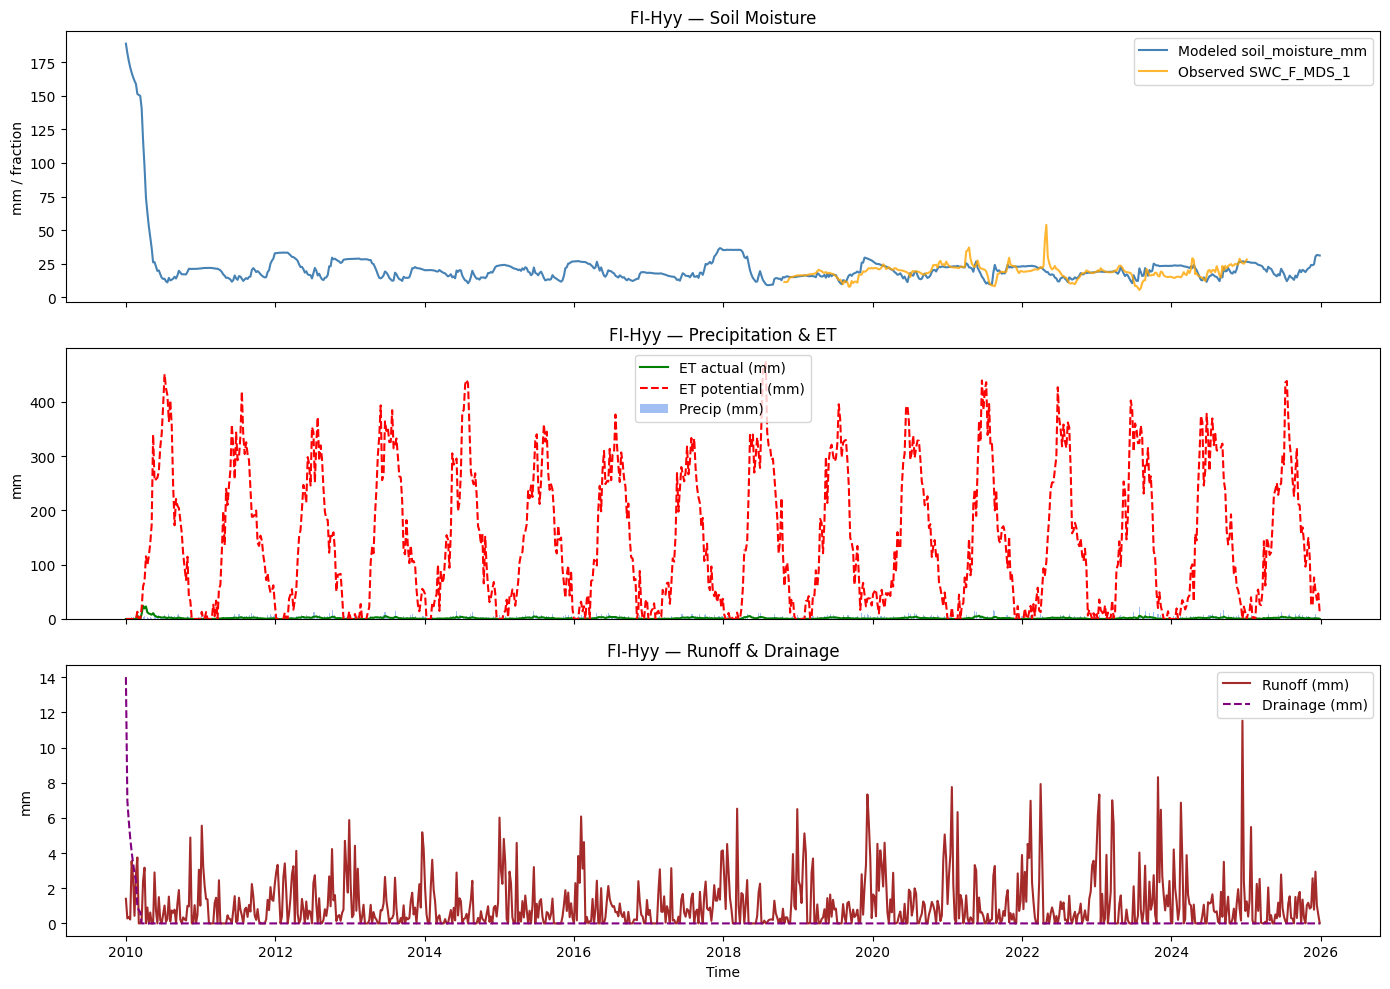

In [9]:
results_all_sites = pd.read_parquet("/home/vm/Desktop/results_all_sites.parquet")
site = results_all_sites.index.get_level_values("site_name").unique()[0]
site_df = results_all_sites.xs(site, level="site_name").reset_index()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# Soil moisture: modeled vs observed
axes[0].plot(site_df["time"], site_df["soil_moisture_mm"], label="Modeled soil_moisture_mm", color="steelblue")
if "SWC_F_MDS_1" in site_df.columns:
    axes[0].plot(site_df["time"], site_df["SWC_F_MDS_1"], label="Observed SWC_F_MDS_1", color="orange", alpha=0.8)
axes[0].set_title(f"{site} — Soil Moisture")
axes[0].set_ylabel("mm / fraction")
axes[0].legend()

# Precipitation and ET
axes[1].bar(site_df["time"], site_df["precip_mm"], label="Precip (mm)", color="cornflowerblue", alpha=0.6, width=5)
axes[1].plot(site_df["time"], site_df["et_actual_mm"], label="ET actual (mm)", color="green")
axes[1].plot(site_df["time"], site_df["et_potential_mm"], label="ET potential (mm)", color="red", linestyle="--")
axes[1].set_title(f"{site} — Precipitation & ET")
axes[1].set_ylabel("mm")
axes[1].legend()

# Runoff and drainage
axes[2].plot(site_df["time"], site_df["runoff_mm"], label="Runoff (mm)", color="brown")
axes[2].plot(site_df["time"], site_df["drainage_mm"], label="Drainage (mm)", color="purple", linestyle="--")
axes[2].set_title(f"{site} — Runoff & Drainage")
axes[2].set_ylabel("mm")
axes[2].set_xlabel("Time")
axes[2].legend()

fig.tight_layout()
plt.show()

In [ ]:
# Use icosSites if it exists, otherwise fall back to icosStations
sites_df = icosSites if "icosSites" in globals() else icosStations

all_results = []
failed_sites = []
failed_swc = []

for site_name in sites_df["Id"].dropna().unique():
    try:
        # ---------- Model inputs ----------
        D_site = xr.open_dataset(f"/mnt/shared/pyrealm2/inputData/{site_name}_weekly_final_variables.nc")

        site_meta = sites_df.loc[sites_df["Id"] == site_name].iloc[0]
        elevation = float(site_meta["Elevation above sea"])
        plant_type = site_meta["plant_type"] if "plant_type" in site_meta.index else np.nan

        lai_to_biomass_multiplier = {
            "tree": 600.0,
            "shrub": 100.0,
            "grass": 100.0,
            "crop": 200.0,
        }.get(str(plant_type).strip().lower(), 100.0)

        biomass = D_site.modis_lai[:, 0, 0].data * lai_to_biomass_multiplier
        clay_pct = float(D_site.attrs["clay_fraction"])

        example_site = pd.DataFrame({
            "time": D_site.time.data,
            "temp_c": D_site.temperature_celcius[:, 0, 0].data,
            "precip_mm": D_site.precipitation_mm[:, 0, 0].data,
            "biomass_gC_m2": biomass,
        })

        out_site = simulate_soil_water_balance(
            example_site,
            date_col="time",
            elevation_m=elevation,
            clay_pct=clay_pct
        )
        out_site["time"] = pd.to_datetime(out_site["time"])

        # ---------- Observed SWC from FLUXNET ----------
        try:
            D_flux = pd.read_csv(
                f"/mnt/shared/pyrealm2/ICOS_ETC_ARCHIVE/tmp_{site_name}/ICOSETC_{site_name}_FLUXNET_HH_L2.csv"
            )
            site_csv_df = D_flux.copy()
            site_csv_df["TIMESTAMP"] = pd.to_datetime(
                site_csv_df["TIMESTAMP_START"].astype(str), format="%Y%m%d%H%M"
            )
            site_csv_df["SWC_F_MDS_1"] = site_csv_df["SWC_F_MDS_1"].replace(-9999, np.nan)

            swc_weekly_site = (
                site_csv_df.assign(
                    time=site_csv_df["TIMESTAMP"].dt.to_period("W-FRI").dt.end_time.dt.normalize()
                )
                .groupby("time", as_index=False)["SWC_F_MDS_1"]
                .mean()
            )

            out_site = out_site.merge(swc_weekly_site, on="time", how="left")

        except Exception as e:
            out_site["SWC_F_MDS_1"] = np.nan
            failed_swc.append((site_name, str(e)))

        out_site["site_name"] = site_name
        out_site["plant_type"] = plant_type
        all_results.append(out_site)

    except Exception as e:
        failed_sites.append((site_name, str(e)))

results_all_sites = (
    pd.concat(all_results, ignore_index=True)
    .set_index(["time", "site_name", "plant_type"])
    .sort_index()
)

print(f"Done. Successful sites: {len(all_results)} | Failed model sites: {len(failed_sites)} | Failed SWC loads: {len(failed_swc)}")
if failed_sites:
    print("Model failed (first 5):", failed_sites[:5])
if failed_swc:
    print("SWC load failed (first 5):", failed_swc[:5])

results_all_sites


In [ ]:
results_all_sites.columns

In [ ]:

# Choose outputs to visualize (simulation outputs, not raw drivers)
output_cols = [
    "soil_moisture_mm",
    "relative_soil_moisture",
    "water_stress",
    "runoff_mm",
    "drainage_mm",
    "et_actual_mm",
    "et_potential_mm",
    "intercepted_mm",
    "throughfall_mm",
    "kc",
]

# Keep only columns that exist
output_cols = [c for c in output_cols if c in results_all_sites.columns]

# Mean weekly per plant_type for model outputs
weekly_mean = (
    results_all_sites[output_cols]
    .groupby(level=["time", "plant_type"])
    .mean()
    .reset_index()
)
weekly_mean["time"] = pd.to_datetime(weekly_mean["time"])

# Mean weekly per plant_type for comparison subplot
comp_df = (
    results_all_sites[["soil_moisture_mm", "SWC_F_MDS_1"]]
    .groupby(level=["time", "plant_type"])
    .mean()
    .reset_index()
    .dropna(subset=["soil_moisture_mm", "SWC_F_MDS_1"])
)

# Fixed plant type colors
color_map = {
    "crop": "orange",
    "grass": "green",
    "shrub": "blue",
    "tree": "red",
}

# Build subplot grid (+1 for comparison subplot)
n = len(output_cols) + 1
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.2 * nrows), sharex=False)
axes = np.array(axes).reshape(-1)

# Time-series subplots
for i, col in enumerate(output_cols):
    plot_df = weekly_mean.pivot(index="time", columns="plant_type", values=col)
    plot_df = plot_df.rename(columns={"shurb": "shrub"})
    ordered_types = [pt for pt in ["crop", "grass", "shrub", "tree"] if pt in plot_df.columns]

    if ordered_types:
        plot_df[ordered_types].plot(
            ax=axes[i],
            linewidth=1.2,
            legend=False,
            color=[color_map[pt] for pt in ordered_types],
        )

    axes[i].set_title(f"Mean Weekly {col}")
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel(col)

# Comparison subplot: modeled soil moisture vs observed SWC
ax_cmp = axes[len(output_cols)]
for pt in ["crop", "grass", "shrub", "tree"]:
    d = comp_df[comp_df["plant_type"] == pt]
    if not d.empty:
        ax_cmp.scatter(
            d["soil_moisture_mm"],
            d["SWC_F_MDS_1"],
            s=16,
            alpha=0.55,
            color=color_map[pt],
            label=pt
        )

# 1:1 reference line
x = comp_df["soil_moisture_mm"]
y = comp_df["SWC_F_MDS_1"]
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax_cmp.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.2, label="1:1")
ax_cmp.set_xlim(lo, hi)
ax_cmp.set_ylim(lo, hi)

# Metrics (overall): r, RMSE, bias (modeled - observed)
if len(comp_df) > 1:
    r = np.corrcoef(x, y)[0, 1]
    rmse = np.sqrt(np.mean((x - y) ** 2))
    bias = np.mean(x - y)

    ax_cmp.text(
        0.02, 0.98,
        f"r = {r:.3f}\nRMSE = {rmse:.2f}\nBias = {bias:.2f}",
        transform=ax_cmp.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray")
    )

ax_cmp.set_title("Soil moisture vs SWC_F_MDS_1")
ax_cmp.set_xlabel("Modeled soil_moisture_mm")
ax_cmp.set_ylabel("Observed SWC_F_MDS_1")

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].axis("off")

# Single legend for whole figure
handles, labels = ax_cmp.get_legend_handles_labels()
if labels:
    fig.legend(handles, labels, title="plant_type", loc="upper center", ncol=min(6, len(labels)))

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()